Adavanced: Model Atmospheres
============================

Setup
-----------------------------

##### Let's first make sure we have the latest version of PHOEBE 2.5 installed (uncomment this line if running in an online notebook session such as colab).

In [1]:
#!pip install -I "phoebe>=2.5"

As of v2.5, model atmospheres in PHOEBE are handled by a new ModelAtmosphere class which provides a framework both for handling model spectra when creating (or updating) PHOEBE passband files, as well as registering the parameters covered by the model atmosphere (such as effective temperature and surface gravity) that are referred to as 'basic_axes'

Let's load the models and see which are currently incorporated

In [2]:
import phoebe
from phoebe.atmospheres import models
import matplotlib.pyplot as plt

models._atmtable

{'extern_planckint': phoebe.atmospheres.models.WDBlackbodyModelAtmosphere,
 'extern_atmx': phoebe.atmospheres.models.WDKurucz93ModelAtmosphere,
 'blackbody': phoebe.atmospheres.models.BlackbodyModelAtmosphere,
 'ck2004': phoebe.atmospheres.models.CK2004ModelAtmosphere,
 'phoenix': phoebe.atmospheres.models.PhoenixModelAtmosphere,
 'tremblay': phoebe.atmospheres.models.TremblayModelAtmosphere,
 'tmap_DO': phoebe.atmospheres.models.TMAPDOModelAtmosphere,
 'tmap_DA': phoebe.atmospheres.models.TMAPDAModelAtmosphere,
 'tmap_sdO': phoebe.atmospheres.models.TMAPsdOModelAtmosphere,
 'tmap_DAO': phoebe.atmospheres.models.TMAPDAOModelAtmosphere}

This tells us that, for example, the PHOEBE default atmosphere 'ck2004' corresponds to the 'CK2004ModelAtmosphere' class

Now let's look more closely at the properties of the 'CK2004ModelAtmosphere' class

In [3]:
dir(models.CK2004ModelAtmosphere)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_recompute_indices',
 'add_axis_node',
 'basic_axis_names',
 'external',
 'from_path',
 'limb_treatment',
 'mus',
 'name',
 'parse_rules',
 'prefix',
 'register',
 'units',
 'wls']

The two most interesting of these are (probably) 'basic_axis_names' and 'mus'

'basic_axis_names' defines the parameter axes that span the model atmosphere grid.

In [4]:
models.CK2004ModelAtmosphere.basic_axis_names

['teffs', 'loggs', 'abuns']

In [5]:
models.TMAPsdOModelAtmosphere.basic_axis_names

['teffs', 'loggs', 'loghefrac']

As seen above, these can be different for different atmospheres which require different parameterisations.  Here, the 'ck2004' grid spans a range of effective temperatures ('teffs'), surface gravities ('loggs') and metallicities ('abuns'), while 'tmap_sdO' covers effective temperatures, surface gravities and the logarithmic He/H fraction by mass ('loghefrac').

Model atmosphere grids can, in principle, span any number of basic axes but effective temperature could be considered a bare minimum.

In [6]:
models.BlackbodyModelAtmosphere.basic_axis_names

['teffs']

'mus' contains the hard-coded range of angles (where mu=cos(theta)) across the stellar limb for which model spectra are available.  These are essentially the anchor points at which the limb-darkening of the model atmosphere is measured.  These again vary from atmosphere to atmosphere, and may sometimes be useful when attempting to understand the fidelity of model atmosphere limb-darkening for a given use case.

In [7]:
models.CK2004ModelAtmosphere.mus

array([0.   , 0.001, 0.002, 0.003, 0.005, 0.01 , 0.015, 0.02 , 0.025,
       0.03 , 0.035, 0.04 , 0.045, 0.05 , 0.06 , 0.07 , 0.08 , 0.09 ,
       0.1  , 0.15 , 0.2  , 0.25 , 0.3  , 0.35 , 0.4  , 0.45 , 0.5  ,
       0.55 , 0.6  , 0.65 , 0.7  , 0.75 , 0.8  , 0.85 , 0.9  , 0.95 ,
       1.   ])

In [8]:
models.TMAPsdOModelAtmosphere.mus

array([0.        , 0.00136799, 0.00719419, 0.01761889, 0.03254691,
       0.05183939, 0.07531619, 0.10275816, 0.13390887, 0.16847785,
       0.20614219, 0.24655013, 0.28932435, 0.33406564, 0.38035639,
       0.42776398, 0.47584619, 0.52415388, 0.57223605, 0.6196437 ,
       0.66593427, 0.71067559, 0.75344991, 0.79385786, 0.83152216,
       0.86609102, 0.89724188, 0.92468378, 0.9481606 , 0.96745302,
       0.98238112, 0.99280576, 0.99863193, 1.        ])

Atmosphere models that do not contain limb-darkening information ('blackbody', for example), will not have the 'mus' attribute and thus require the 'ld_func' to be set to something other than 'interp' as described in the [Atmospheres & Passbands](./atm_passbands.ipynb) tutorial.

In [9]:
models.BlackbodyModelAtmosphere.mus

AttributeError: type object 'BlackbodyModelAtmosphere' has no attribute 'mus'

Returning to the basic axes, in order to access the actual values that the grid spans, we will need to load a passband file.

In [10]:
pb=phoebe.get_passband("Johnson:V")

The ndpolator then allows us to see the various tables contained within the passband, where N tells us the number of basic axes.

In [11]:
pb.ndp

{'blackbody': <Ndpolator N=1, 4 tables>,
 'ck2004': <Ndpolator N=3, 10 tables>,
 'phoenix': <Ndpolator N=3, 10 tables>,
 'tremblay': <Ndpolator N=2, 10 tables>,
 'tmap_DO': <Ndpolator N=2, 10 tables>,
 'tmap_DA': <Ndpolator N=2, 10 tables>,
 'tmap_sdO': <Ndpolator N=3, 10 tables>,
 'tmap_DAO': <Ndpolator N=3, 10 tables>}

We can then access the grid points of the basic axes via the 'axes' property of a given model atmosphere

In [12]:
pb.ndp['ck2004'].axes

(array([ 3500.,  3750.,  4000.,  4250.,  4500.,  4750.,  5000.,  5250.,
         5500.,  5750.,  6000.,  6250.,  6500.,  6750.,  7000.,  7250.,
         7500.,  7750.,  8000.,  8250.,  8500.,  8750.,  9000.,  9250.,
         9500.,  9750., 10000., 10250., 10500., 10750., 11000., 11250.,
        11500., 11750., 12000., 12250., 12500., 12750., 13000., 14000.,
        15000., 16000., 17000., 18000., 19000., 20000., 21000., 22000.,
        23000., 24000., 25000., 26000., 27000., 28000., 29000., 30000.,
        31000., 32000., 33000., 34000., 35000., 36000., 37000., 38000.,
        39000., 40000., 41000., 42000., 43000., 44000., 45000., 46000.,
        47000., 48000., 49000., 50000.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 array([-2.5, -2. , -1.5, -1. , -0.5,  0. ,  0.2,  0.5]))

This shows that the default 'ck2004' grid spans 3500 to 50000 K in effective temperature ('teffs'), 0.0 to 5.0 in surface gravity ('loggs') and -2.5 to 0.5 in metallicity ('abuns').

Now let's iteratively access the model atmosphere axes to make a Kiel diagram (effective temperature versus surface gravity) showing the coverage of the various atmosphere models.

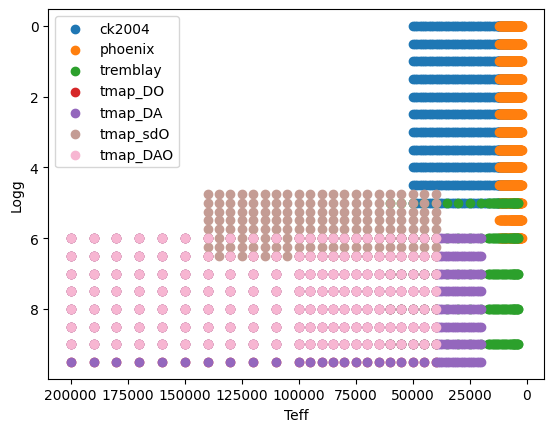

In [13]:
cmap = plt.get_cmap('tab20', len(models._atmtable))

atmindex=0
for atmosphere in models._atmtable:
    if set(['teffs', 'loggs']).issubset(models._atmtable[atmosphere].basic_axis_names) and 'extern' not in atmosphere:
        atmteffs=pb.ndp[atmosphere].axes[models._atmtable[atmosphere].basic_axis_names.index('teffs')]
        atmloggs=pb.ndp[atmosphere].axes[models._atmtable[atmosphere].basic_axis_names.index('loggs')]
        for i in range(0,len(atmteffs)):
            if i==0:
                plt.scatter([atmteffs[i]] * len(atmloggs), atmloggs, label=atmosphere, color=cmap(atmindex))
            else:
                plt.scatter([atmteffs[i]] * len(atmloggs), atmloggs, color=cmap(atmindex))
        atmindex+=1
        plt.legend()
        plt.xlabel('Teff')
        plt.ylabel('Logg')
        plt.gca().invert_xaxis()
        plt.gca().invert_yaxis()

